# Data Loading

In [33]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [2]:
# Setting up visual styles
sns.set_theme(style="whitegrid")
%matplotlib inline

In [3]:
# Loading the datasets
try:
    customers = pd.read_csv('/content/customers.csv')
    orders = pd.read_csv('/content/orders.csv')
    order_items = pd.read_csv('/content/order_items.csv')
    payments = pd.read_csv('/content/payments.csv')
    products = pd.read_csv('/content/products.csv')
    sellers = pd.read_csv('/content/sellers.csv')

    print("All 6 files loaded successfully!")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure all CSV files are uploaded to Colab.")

All 6 files loaded successfully!


In [4]:
# Displaying first 2 rows and Shape of each dataframe to verify
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Products": products,
    "Sellers": sellers
}

for name, df in datasets.items():
    print(f"\n--- {name} Dataset ---")
    print(f"Shape: {df.shape}")
    display(df.head(2))


--- Customers Dataset ---
Shape: (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP



--- Orders Dataset ---
Shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 0:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 3:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 0:00:00



--- Order Items Dataset ---
Shape: (112650, 7)


...

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39



--- Products Dataset ---
Shape: (32951, 9)


,product_id,product category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,Art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0



--- Sellers Dataset ---
Shape: (3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP


# Data Cleaning

In [5]:
# Renaming Columns for consistency (removing spaces, lowercase)
products.rename(columns={'product category': 'product_category'}, inplace=True)

In [6]:
# Handling Missing Values: In 'products', if category is missing, we'll fill with 'unknown'
products['product_category'] = products['product_category'].fillna('unknown')

In [7]:
# Converting Date/Timestamp columns to Datetime objects for time-based analysis
date_columns = {
    'orders': ['order_purchase_timestamp', 'order_approved_at',
               'order_delivered_carrier_date', 'order_delivered_customer_date',
               'order_estimated_delivery_date'],
    'order_items': ['shipping_limit_date']
}

for table_name, cols in date_columns.items():
    df = globals()[table_name] # Access the dataframe by string name
    for col in cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [8]:
# Checking for Duplicates
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"Removing {duplicates} duplicates from {name}")
        df.drop_duplicates(inplace=True)

In [9]:
# Handling Nulls in sensitive columns. For 'orders', we only want to keep rows where the purchase timestamp is valid
orders.dropna(subset=['order_purchase_timestamp'], inplace=True)

In [10]:
# Verifying Data Types after cleaning
print("\n--- Data Cleaning Complete ---")
print(f"Orders Date Types:\n{orders.dtypes[orders.dtypes == 'datetime64[ns]']}")
print(f"\nMissing values in Products:\n{products.isnull().sum()}")


--- Data Cleaning Complete ---
Orders Date Types:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Missing values in Products:
product_id                      0
product_category                0
product_name_length           610
product_description_length    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [11]:
# Final Check on Shapes
print(f"\nCleaned shapes: Orders {orders.shape}, Products {products.shape}")


Cleaned shapes: Orders (99441, 8), Products (32951, 9)


# Data Visualization

Merging all dataframes into a Master Table

In [12]:
# Start with Orders and link Customers
df_master = pd.merge(orders, customers, on='customer_id', how='left')

In [13]:
# Add Order Items (This expands the table to a per-item level)
df_master = pd.merge(df_master, order_items, on='order_id', how='left')

In [14]:
# Add Product details
df_master = pd.merge(df_master, products, on='product_id', how='left')

In [15]:
# Add Seller details
df_master = pd.merge(df_master, sellers, on='seller_id', how='left')

In [16]:
# Add Payment details
# Note: If an order has multiple payments (e.g., 2 different cards), this will create a row for each payment.
df_master = pd.merge(df_master, payments, on='order_id', how='left')

In [17]:
# Final Check
print(f"Master Table Created!")
print(f"Total Rows: {df_master.shape[0]}")
print(f"Total Columns: {df_master.shape[1]}")

Master Table Created!
Total Rows: 118434
Total Columns: 33


In [18]:
# Exporting the master table for record-keeping
df_master.to_csv('master_data.csv', index=False)

In [19]:
# Displaying the first 5 rows of the Master Table
display(df_master.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,31570.0,belo horizonte,SP,1.0,UPI,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,14840.0,guariba,SP,1.0,credit_card,3.0,179.12


## Basic Problems
---
Objective: Extract fundamental insights from the dataset.

1. List all unique cities where customers are located.

Total Unique Cities Found: 4119

Table: Top 10 Cities by Customer Count


,City,Customer_Count
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
5,campinas,1444
6,porto alegre,1379
7,salvador,1245
8,guarulhos,1189
9,sao bernardo do campo,938


/tmp/ipython-input-164/476853059.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_cities, x='Customer_Count', y='City', palette='viridis')


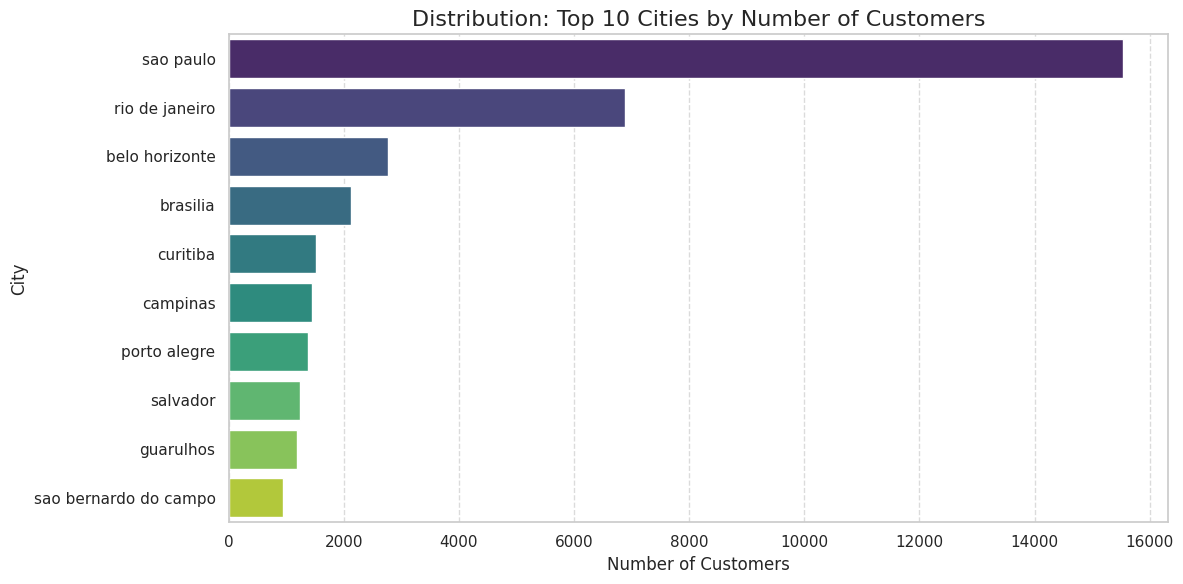

In [20]:
# Get unique cities
unique_cities_series = customers['customer_city'].unique()
unique_cities_df = pd.DataFrame(sorted(unique_cities_series), columns=['Unique_Cities'])

# Prepare data for Visual and its Table (Top 10 Cities)
top_10_cities = customers['customer_city'].value_counts().head(10).reset_index()
top_10_cities.columns = ['City', 'Customer_Count']

# Table
print(f"Total Unique Cities Found: {len(unique_cities_series)}")
print("\nTable: Top 10 Cities by Customer Count")
display(top_10_cities)

# Visual
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_cities, x='Customer_Count', y='City', palette='viridis')

plt.title('Distribution: Top 10 Cities by Number of Customers', fontsize=16)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('top_10_cities.png')
plt.show()

2. Count the number of orders placed in 2017.

Total Orders Placed in 2017: 45101

Table: Monthly Order Breakdown for 2017


,month_name,Total Orders
0,January,800
1,February,1780
2,March,2682
3,April,2404
4,May,3700
5,June,3245
6,July,4026
7,August,4331
8,September,4285
9,October,4631


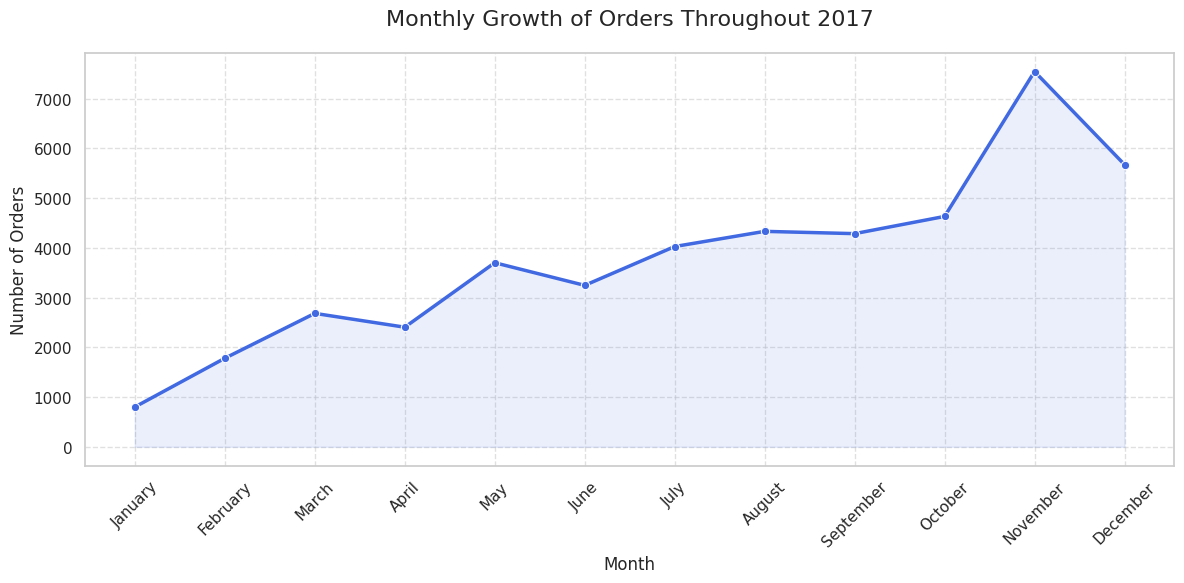

In [21]:
# 1. Filter orders for the year 2017
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders_2017 = orders[orders['order_purchase_timestamp'].dt.year == 2017].copy()

# Monthly Table
orders_2017['month'] = orders_2017['order_purchase_timestamp'].dt.month
orders_2017['month_name'] = orders_2017['order_purchase_timestamp'].dt.strftime('%B')

# Grouping by month to show the distribution
monthly_table = orders_2017.groupby(['month', 'month_name']).size().reset_index(name='Total Orders')
monthly_table = monthly_table.sort_values('month')[['month_name', 'Total Orders']]

# Table
print(f"Total Orders Placed in 2017: {len(orders_2017)}")
print("\nTable: Monthly Order Breakdown for 2017")
display(monthly_table)

# Visual
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_table, x='month_name', y='Total Orders', marker='o', color='royalblue', linewidth=2.5)
plt.fill_between(monthly_table['month_name'], monthly_table['Total Orders'], color='royalblue', alpha=0.1)

plt.title('Monthly Growth of Orders Throughout 2017', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

3. Find the total sales per category.


Table: Top 10 Product Categories by Total Sales Value


,Product Category,Total Sales
30,HEALTH BEAUTY,1258681.34
45,Watches present,1205005.68
49,bed table bath,1036988.68
68,sport leisure,988048.97
53,computer accessories,911954.32
24,Furniture Decoration,729762.49
13,Cool Stuff,635290.85
61,housewares,632248.66
47,automotive,592720.11
28,Garden tools,485256.46


/tmp/ipython-input-164/3499043586.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_sales, x='Total Sales', y='Product Category', palette='rocket')


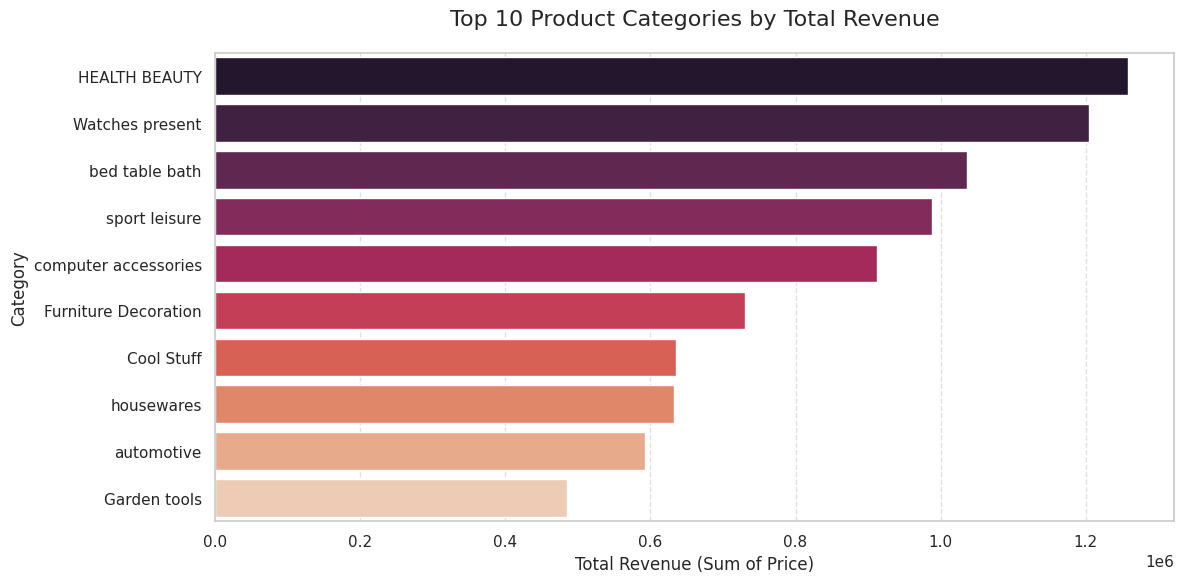

In [22]:
# Merge Order Items and Products
sales_data = pd.merge(order_items[['product_id', 'price']], products[['product_id', 'product_category']], on='product_id', how='left')

# Aggregation: Sum price per category
category_sales = sales_data.groupby('product_category')['price'].sum().reset_index()
category_sales.columns = ['Product Category', 'Total Sales']

# Sorting to get the top performers
category_sales = category_sales.sort_values(by='Total Sales', ascending=False)
top_10_sales = category_sales.head(10)

# Table
print("Table: Top 10 Product Categories by Total Sales Value")
display(top_10_sales)

# Visual
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_sales, x='Total Sales', y='Product Category', palette='rocket')

plt.title('Top 10 Product Categories by Total Revenue', fontsize=16, pad=20)
plt.xlabel('Total Revenue (Sum of Price)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

4. Calculate the percentage of orders that were paid in installments.

Total Unique Orders Analyzed: 99440

Table: Installment vs Full Payment Distribution


,Payment Method,Total Orders,Percentage
0,Installments,51170,51.46
1,Full Payment,48270,48.54


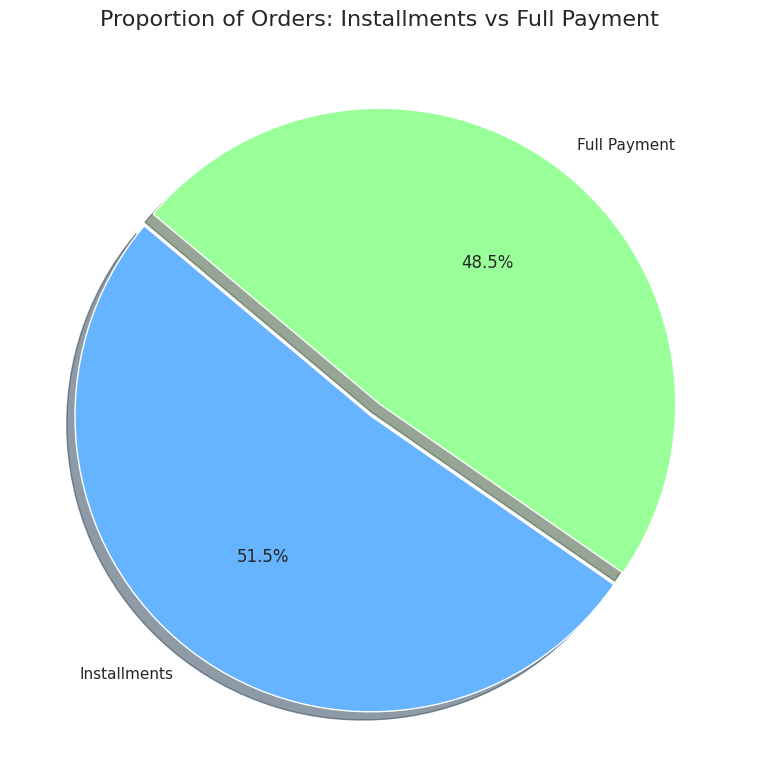

In [23]:
# We group by order_id because one order might have multiple payment entries
order_installments = payments.groupby('order_id')['payment_installments'].max().reset_index()
order_installments['payment_type_category'] = order_installments['payment_installments'].apply(
    lambda x: 'Installments' if x > 1 else 'Full Payment'
)

# Count orders per payment type
installment_stats = order_installments['payment_type_category'].value_counts().reset_index()
installment_stats.columns = ['Payment Method', 'Total Orders']

# Calculate Percentage
total_unique_orders = len(order_installments)
installment_stats['Percentage'] = (installment_stats['Total Orders'] / total_unique_orders * 100).round(2)

# Table
print(f"Total Unique Orders Analyzed: {total_unique_orders}")
print("\nTable: Installment vs Full Payment Distribution")
display(installment_stats)

# Visual
plt.figure(figsize=(8, 8))
colors = ['#66b3ff','#99ff99']
plt.pie(installment_stats['Total Orders'],
        labels=installment_stats['Payment Method'],
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=(0.05, 0),
        shadow=True)

plt.title('Proportion of Orders: Installments vs Full Payment', fontsize=16)
plt.tight_layout()
plt.show()

5. Count the number of customers from each state.

Table: Number of Customers by State


,State,Customer Count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


/tmp/ipython-input-164/252823542.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_counts, x='State', y='Customer Count', palette='coolwarm')


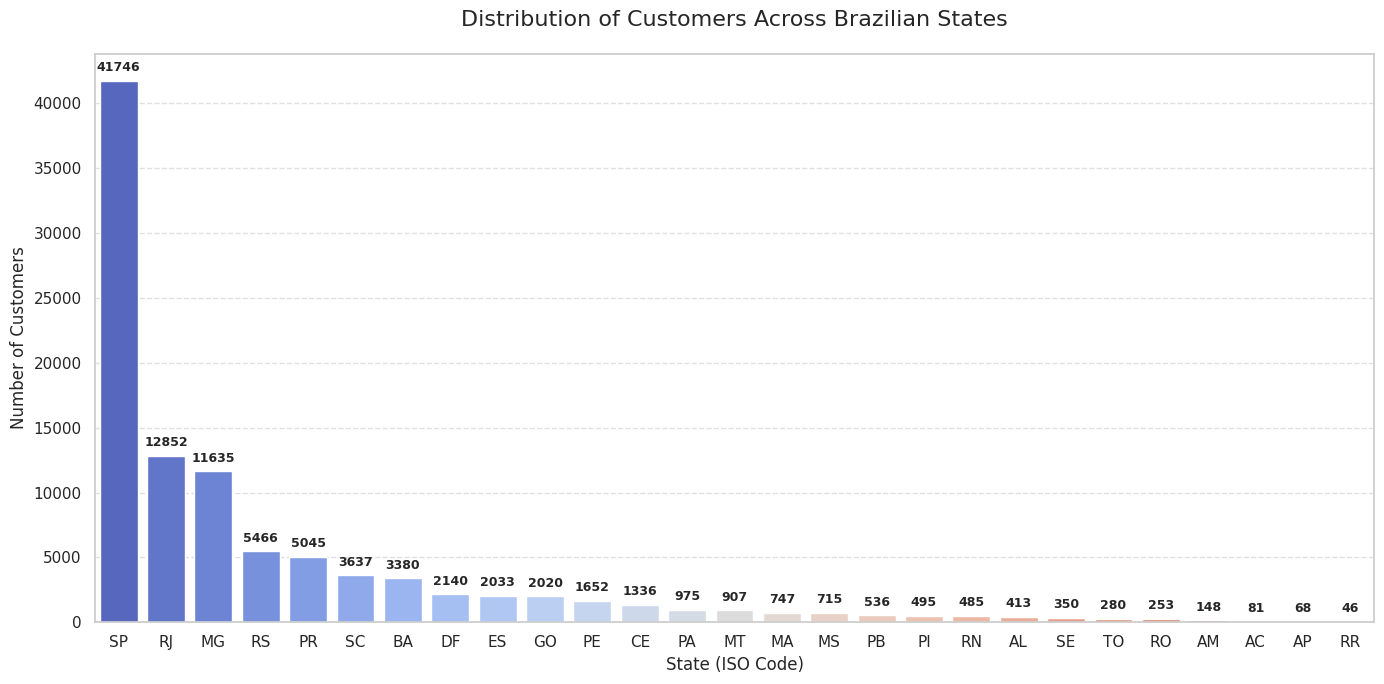

In [24]:
# Count customers per state
state_counts = customers['customer_state'].value_counts().reset_index()
state_counts.columns = ['State', 'Customer Count']

# Table
print("Table: Number of Customers by State")
display(state_counts)

# Visual
plt.figure(figsize=(14, 7))
# Sorting by count for a better visual flow
sns.barplot(data=state_counts, x='State', y='Customer Count', palette='coolwarm')

plt.title('Distribution of Customers Across Brazilian States', fontsize=16, pad=20)
plt.xlabel('State (ISO Code)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add data labels on top of bars for clarity
for i, count in enumerate(state_counts['Customer Count']):
    plt.text(i, count + 500, f'{count}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Intermediate Problems
---
Objective: Dive deeper into sales and order trends.

1. Calculate the number of orders per month in 2018.

Table: Number of Orders per Month in 2018


,month_name,Total Orders
0,January,7269
1,February,6728
2,March,7211
3,April,6939
4,May,6873
5,June,6167
6,July,6292
7,August,6512
8,September,16
9,October,4


/tmp/ipython-input-164/1798756735.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_orders, x='month_name', y='Total Orders', palette='viridis')


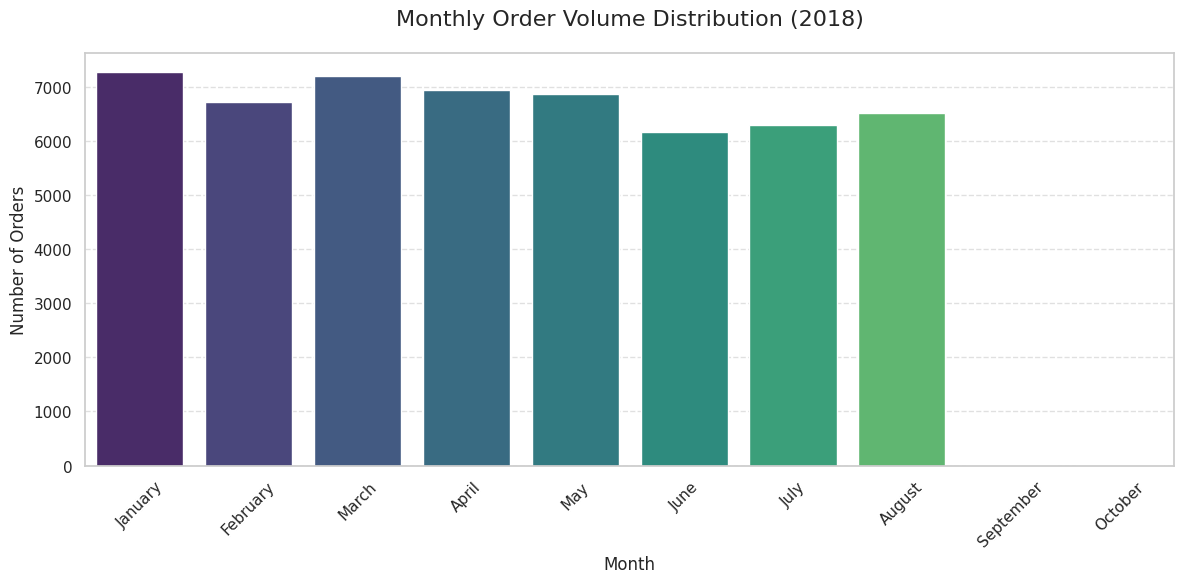

In [25]:
# Filter for orders specifically in 2018
orders_2018 = orders[orders['order_purchase_timestamp'].dt.year == 2018].copy()

# Extract Month info
orders_2018['month_num'] = orders_2018['order_purchase_timestamp'].dt.month
orders_2018['month_name'] = orders_2018['order_purchase_timestamp'].dt.strftime('%B')

# Group by month
monthly_orders = orders_2018.groupby(['month_num', 'month_name']).size().reset_index(name='Total Orders')
monthly_orders = monthly_orders.sort_values('month_num')[['month_name', 'Total Orders']]

# Table
print("Table: Number of Orders per Month in 2018")
display(monthly_orders)

# Visual
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_orders, x='month_name', y='Total Orders', palette='viridis')

plt.title('Monthly Order Volume Distribution (2018)', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

2. Find the average number of products per order, grouped by customer city.

Table: Top 10 Cities with Highest Average Products per Order


,City,Avg Products per Order
2619,padre carvalho,7.0
907,celso ramos,6.5
1154,datas,6.0
756,candido godoi,6.0
2264,matias olimpio,5.0
2395,morro de sao paulo,4.0
2817,picarra,4.0
1146,curralinho,4.0
955,cidelandia,4.0
3821,teixeira soares,4.0


/tmp/ipython-input-164/1057794568.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_cities_avg, x='Avg Products per Order', y='City', palette='flare')


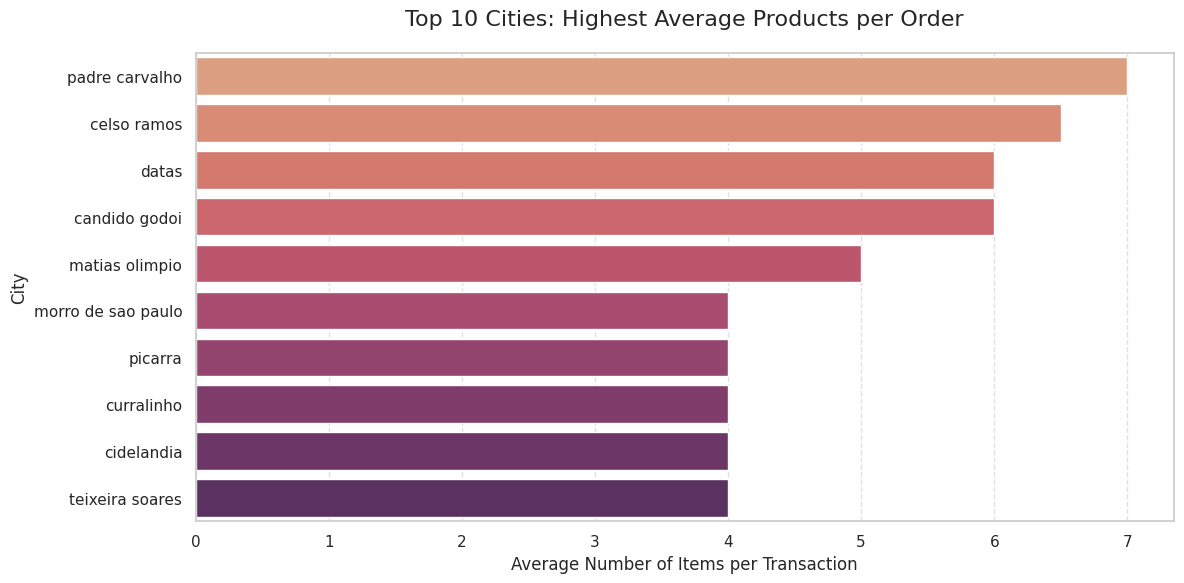

In [26]:
# Calculate items per order
items_per_order = order_items.groupby('order_id').size().reset_index(name='product_count')

# Merge to link orders to cities
order_mapping = pd.merge(items_per_order, orders[['order_id', 'customer_id']], on='order_id')
order_city_data = pd.merge(order_mapping, customers[['customer_id', 'customer_city']], on='customer_id')

# Group by city and calculate average
city_avg_stats = order_city_data.groupby('customer_city')['product_count'].mean().reset_index()
city_avg_stats.columns = ['City', 'Avg Products per Order']

# Sorting for meaningful insights (Top 10)
top_10_cities_avg = city_avg_stats.sort_values(by='Avg Products per Order', ascending=False).head(10)

# Table
print("Table: Top 10 Cities with Highest Average Products per Order")
display(top_10_cities_avg)

# Visual
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_cities_avg, x='Avg Products per Order', y='City', palette='flare')

plt.title('Top 10 Cities: Highest Average Products per Order', fontsize=16, pad=20)
plt.xlabel('Average Number of Items per Transaction', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

3. Calculate the percentage of total revenue contributed by each product category.

Total Marketplace Revenue: $13,591,643.70

Table: Revenue Percentage Contribution by Top 10 Categories


,Product Category,Total Revenue,Percentage (%)
30,HEALTH BEAUTY,1258681.34,9.26
45,Watches present,1205005.68,8.87
49,bed table bath,1036988.68,7.63
68,sport leisure,988048.97,7.27
53,computer accessories,911954.32,6.71
24,Furniture Decoration,729762.49,5.37
13,Cool Stuff,635290.85,4.67
61,housewares,632248.66,4.65
47,automotive,592720.11,4.36
28,Garden tools,485256.46,3.57


/tmp/ipython-input-164/2067162643.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_contribution, x='Percentage (%)', y='Product Category', palette='mako')


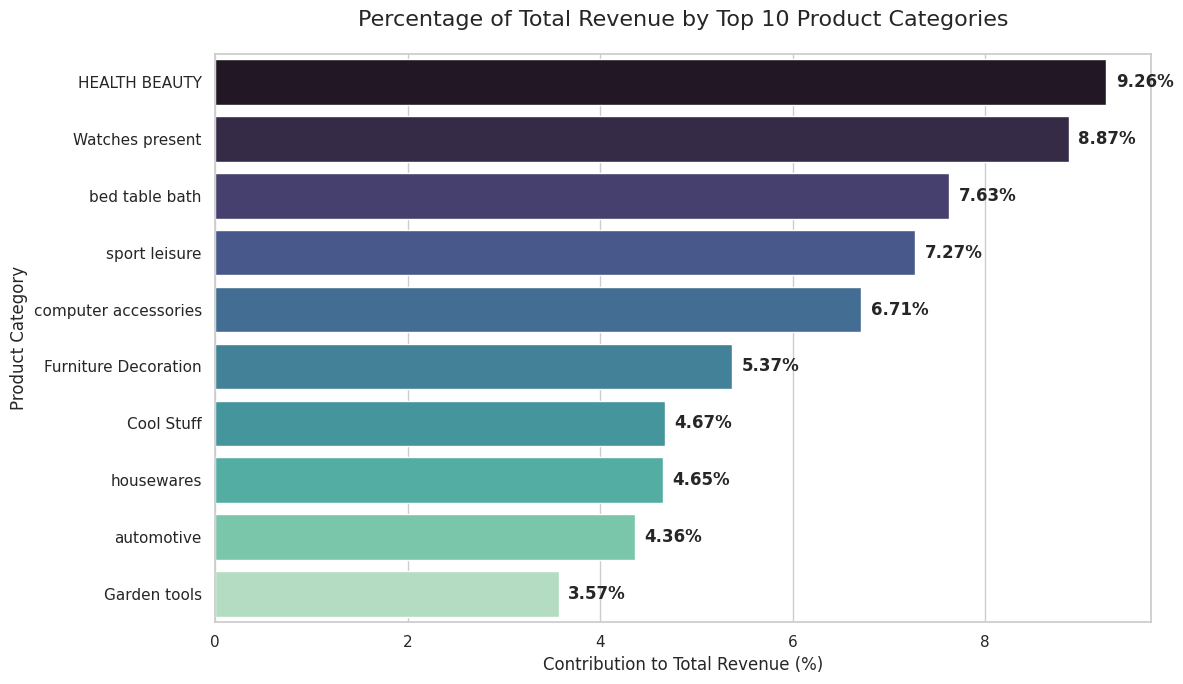

In [27]:
# Join Order Items with Products to link Price to Category
revenue_df = pd.merge(order_items[['product_id', 'price']],
                      products[['product_id', 'product_category']],
                      on='product_id',
                      how='left')

# Calculate Totals
total_marketplace_revenue = revenue_df['price'].sum()

# Sum price per category and calculate percentage
category_contribution = revenue_df.groupby('product_category')['price'].sum().reset_index()
category_contribution.columns = ['Product Category', 'Total Revenue']

category_contribution['Percentage (%)'] = (category_contribution['Total Revenue'] / total_marketplace_revenue * 100).round(2)

# Sort and take top 10
category_contribution = category_contribution.sort_values(by='Total Revenue', ascending=False)
top_10_contribution = category_contribution.head(10)

# Table
print(f"Total Marketplace Revenue: ${total_marketplace_revenue:,.2f}")
print("\nTable: Revenue Percentage Contribution by Top 10 Categories")
display(top_10_contribution)

# Visual
plt.figure(figsize=(12, 7))
sns.barplot(data=top_10_contribution, x='Percentage (%)', y='Product Category', palette='mako')

plt.title('Percentage of Total Revenue by Top 10 Product Categories', fontsize=16, pad=20)
plt.xlabel('Contribution to Total Revenue (%)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

# Adding labels for precise reading
for i, perc in enumerate(top_10_contribution['Percentage (%)']):
    plt.text(perc + 0.1, i, f'{perc}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

4. Identify the correlation between product price and the number of times a product has been purchased.

Pearson Correlation Coefficient: -0.0321

Table: Top 10 Most Purchased Products and their Pricing


,Product ID,Purchase Count,Average Price
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527,71.364137
19742,99a4788cb24856965c36a24e339b6058,488,88.167131
8613,422879e10f46682990de24d770e7f83d,484,54.911612
7364,389d119b48cf3043d311335e499d9c6b,392,54.695383
7079,368c6c730842d78016ad823897a372db,388,54.270103
10840,53759a2ecddad2bb87a079a1f1519f73,373,54.657373
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343,137.651633
10867,53b36df67ebb7c41585e8d54d6772e08,323,116.666935
2794,154e7e31ebfa092203795c972e5804a6,281,22.509573
8051,3dd2a17168ec895c781a9191c1e95ad7,274,149.936496


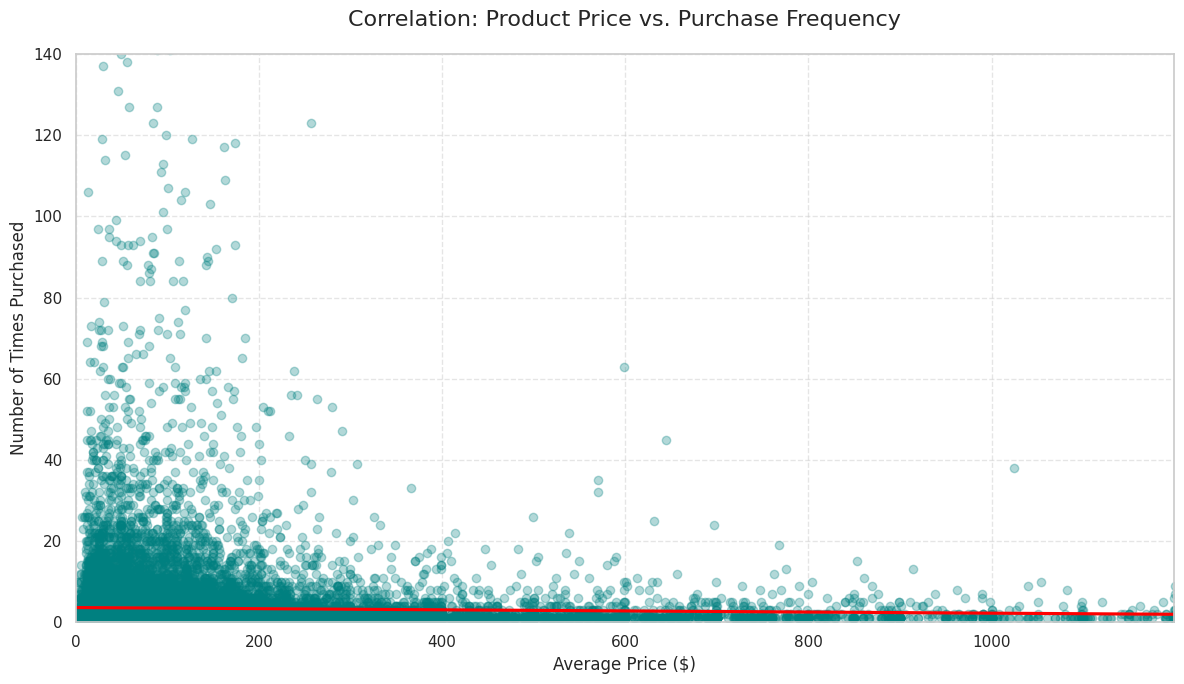

In [28]:
# Calculate Purchase Count and Avg Price per Product
product_stats = order_items.groupby('product_id').agg(
    purchase_count=('order_id', 'count'),
    avg_price=('price', 'mean')
).reset_index()

# Calculate Pearson Correlation Coefficient
correlation = product_stats['avg_price'].corr(product_stats['purchase_count'])

# Table (Top 10 Most Purchased Products)
top_products = product_stats.sort_values(by='purchase_count', ascending=False).head(10)
top_products.columns = ['Product ID', 'Purchase Count', 'Average Price']

print(f"Pearson Correlation Coefficient: {correlation:.4f}")
print("\nTable: Top 10 Most Purchased Products and their Pricing")
display(top_products)

# Visual
plt.figure(figsize=(12, 7))
sns.regplot(data=product_stats, x='avg_price', y='purchase_count',
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'red'})

plt.title('Correlation: Product Price vs. Purchase Frequency', fontsize=16, pad=20)
plt.xlabel('Average Price ($)', fontsize=12)
plt.ylabel('Number of Times Purchased', fontsize=12)

# Adjusting axes to focus on the bulk of the data (removing extreme outliers for better visibility)
plt.xlim(0, product_stats['avg_price'].quantile(0.99))
plt.ylim(0, product_stats['purchase_count'].quantile(0.999))
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

5. Calculate the total revenue generated by each seller, and rank them by revenue.

Table: Top 10 Sellers by Total Revenue Ranking


,Seller ID,Total Revenue,Rank
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1
1013,53243585a1d6dc2643021fd1853d8905,222776.05,2
881,4a3ca9315b744ce9f8e9374361493884,200472.92,3
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,4
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,5
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,6
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,7
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,8
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,9
1824,955fee9216a65b617aa5c0531780ce60,135171.70,10


/tmp/ipython-input-164/3418311561.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_sellers, x='Total Revenue', y='Seller ID', palette='plasma')


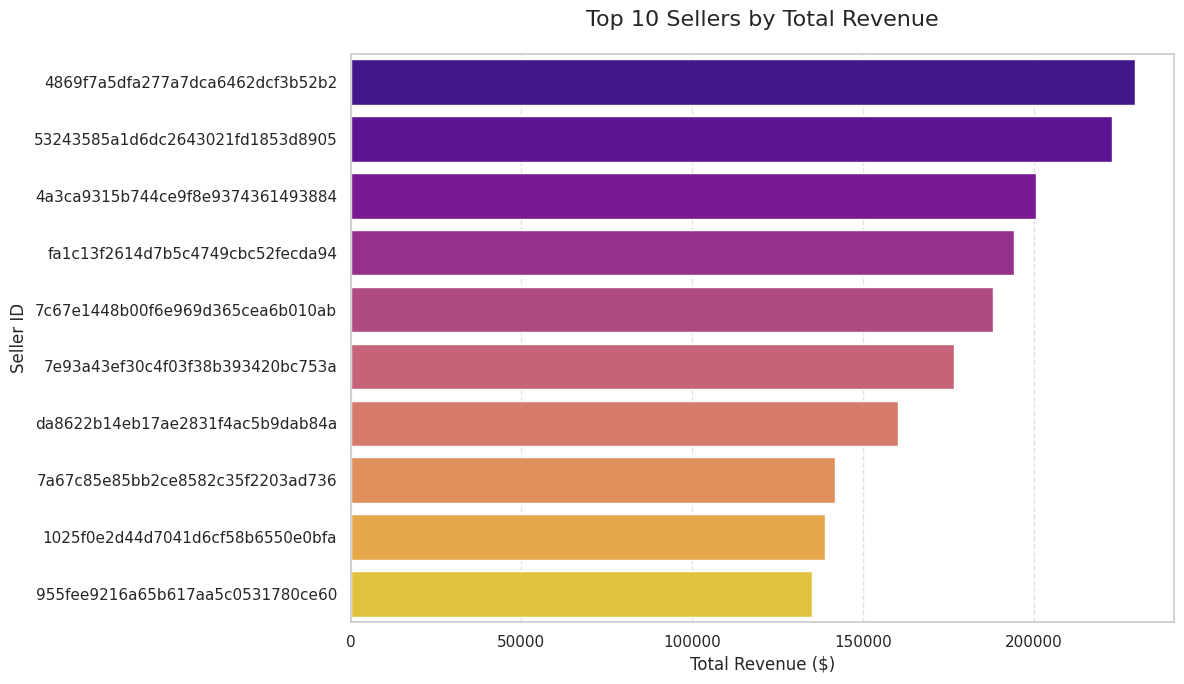

In [29]:
# Calculate total revenue per seller
seller_stats = order_items.groupby('seller_id')['price'].sum().reset_index()
seller_stats.columns = ['Seller ID', 'Total Revenue']

# Sort by revenue and assign a rank
seller_stats = seller_stats.sort_values(by='Total Revenue', ascending=False)
seller_stats['Rank'] = range(1, len(seller_stats) + 1)

# Prepare summary for Top 10
top_10_sellers = seller_stats.head(10)

# Table
print("Table: Top 10 Sellers by Total Revenue Ranking")
display(top_10_sellers)

# Visual
plt.figure(figsize=(12, 7))
sns.barplot(data=top_10_sellers, x='Total Revenue', y='Seller ID', palette='plasma')

plt.title('Top 10 Sellers by Total Revenue', fontsize=16, pad=20)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Seller ID', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Advanced Problems
---
Objective: Generate strategic and customer-centric insights.

1. Calculate the moving average of order values for each customer over their order history.

Table: Sample Customer Order History and Moving Average (Window=2)


,customer_unique_id,order_purchase_timestamp,payment_value,moving_avg
46193,3e43e6105506432c953e165fb2acf44c,2017-09-18 18:53:15,98.72,98.720
14073,3e43e6105506432c953e165fb2acf44c,2017-12-01 09:30:36,115.40,107.060
28925,3e43e6105506432c953e165fb2acf44c,2017-12-01 22:37:41,65.10,90.250
3005,3e43e6105506432c953e165fb2acf44c,2017-12-01 22:37:42,364.18,214.640
85697,3e43e6105506432c953e165fb2acf44c,2018-01-11 10:56:15,132.95,248.565
41708,3e43e6105506432c953e165fb2acf44c,2018-02-12 10:12:54,130.58,131.765
80323,3e43e6105506432c953e165fb2acf44c,2018-02-12 10:12:55,65.87,98.225
53987,3e43e6105506432c953e165fb2acf44c,2018-02-20 10:45:22,76.17,71.020
92503,3e43e6105506432c953e165fb2acf44c,2018-02-27 18:36:39,123.69,99.930
68663,8d50f5eadf50201ccdcedfb9e2ac8455,2017-05-15 23:30:03,22.77,22.770


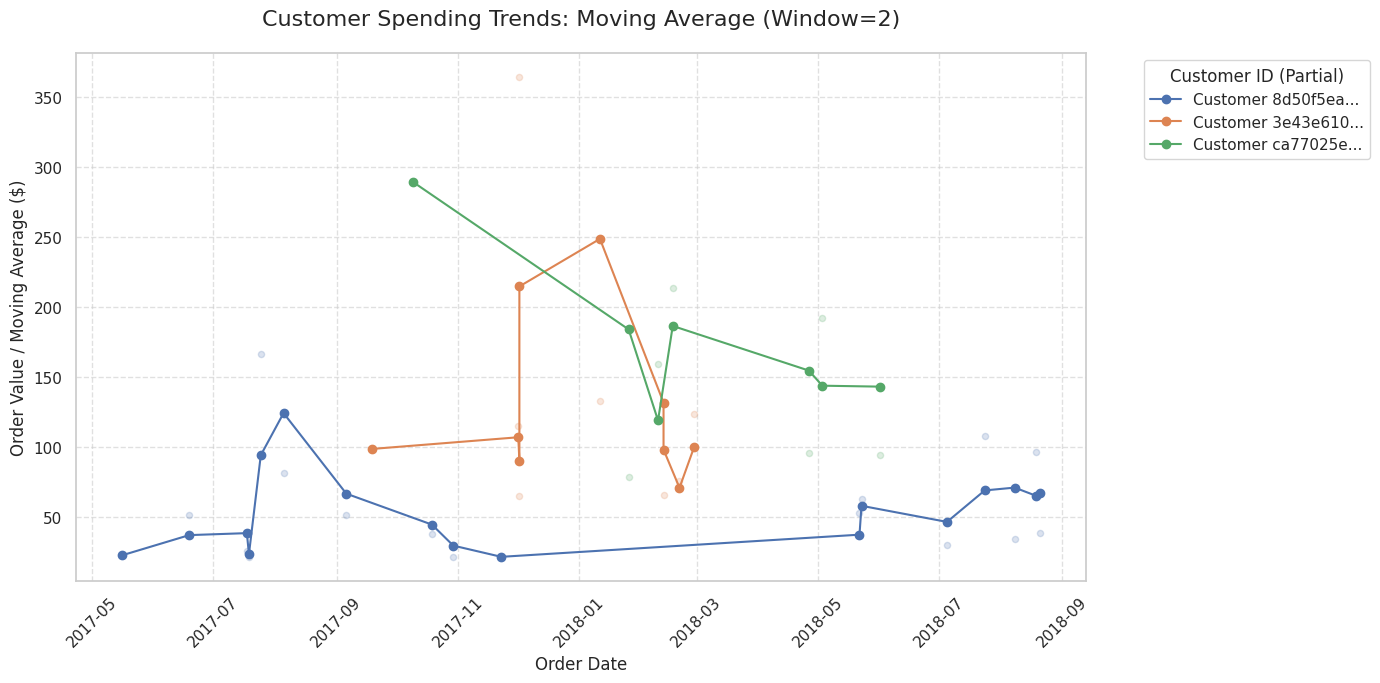

In [30]:
# Sum payment value per order_id
order_values = payments.groupby('order_id')['payment_value'].sum().reset_index()

# Merging to get Customer Unique ID and Timestamp
# We use customer_unique_id to identify the same person across different orders
order_history = pd.merge(orders[['order_id', 'customer_id', 'order_purchase_timestamp']], order_values, on='order_id')
order_history = pd.merge(order_history, customers[['customer_id', 'customer_unique_id']], on='customer_id')

# Sort for sequence
order_history = order_history.sort_values(by=['customer_unique_id', 'order_purchase_timestamp'])

# Moving Average with a window of 2 orders
order_history['moving_avg'] = order_history.groupby('customer_unique_id')['payment_value'].transform(
    lambda x: x.rolling(window=2, min_periods=1).mean()
)

# Filter for Table/Visual: Select customers with the most orders to show history
top_frequent_custs = order_history['customer_unique_id'].value_counts().head(3).index.tolist()
sample_history = order_history[order_history['customer_unique_id'].isin(top_frequent_custs)].copy()

# Table
print("Table: Sample Customer Order History and Moving Average (Window=2)")
display(sample_history[['customer_unique_id', 'order_purchase_timestamp', 'payment_value', 'moving_avg']])

# Visual
plt.figure(figsize=(14, 7))
for cust_id in top_frequent_custs:
    cust_data = sample_history[sample_history['customer_unique_id'] == cust_id]
    plt.plot(cust_data['order_purchase_timestamp'], cust_data['moving_avg'], marker='o', label=f'Customer {cust_id[:8]}...')
    plt.scatter(cust_data['order_purchase_timestamp'], cust_data['payment_value'], alpha=0.2, s=20)

plt.title('Customer Spending Trends: Moving Average (Window=2)', fontsize=16, pad=20)
plt.xlabel('Order Date', fontsize=12)
plt.ylabel('Order Value / Moving Average ($)', fontsize=12)
plt.legend(title="Customer ID (Partial)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

2. Calculate the cumulative sales per month for each year.

Table: Year-to-Date (Cumulative) Sales per Month


year,2016,2017,2018
month_name,,,
January,0,138488,1115004
February,0,430396,2107467
March,0,880259,3267119
April,0,1298047,4427905
May,0,1890966,5581887
June,0,2402242,6605767
July,0,2994625,7672308
August,0,3669022,8694733
September,252,4396784,8699173


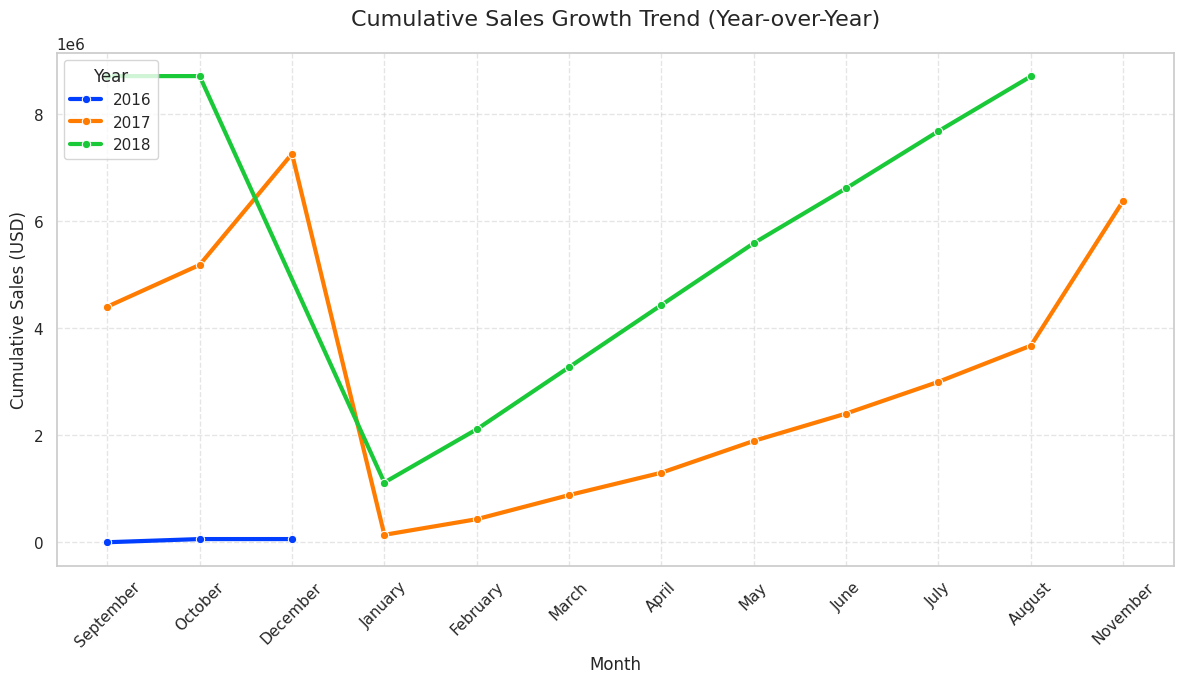

In [34]:
# Sum payments per order first to handle multiple payment methods
order_pay_totals = payments.groupby('order_id')['payment_value'].sum().reset_index()

sales_history = pd.merge(orders[['order_id', 'order_purchase_timestamp', 'order_status']],
                         order_pay_totals, on='order_id')

# Date Processing
sales_history['year'] = sales_history['order_purchase_timestamp'].dt.year
sales_history['month'] = sales_history['order_purchase_timestamp'].dt.month

# Monthly Sales
monthly_totals = sales_history.groupby(['year', 'month'])['payment_value'].sum().reset_index()
monthly_totals = monthly_totals.sort_values(['year', 'month'])

# Cumulative Sum (Year-to-Date)
monthly_totals['cumulative_sales'] = monthly_totals.groupby('year')['payment_value'].cumsum()
monthly_totals['month_name'] = monthly_totals['month'].apply(lambda x: calendar.month_name[x])

# Table (Pivoted for clarity)
ytd_table = monthly_totals.pivot(index='month_name', columns='year', values='cumulative_sales')
month_order = list(calendar.month_name)[1:]
ytd_table = ytd_table.reindex(month_order)

print("Table: Year-to-Date (Cumulative) Sales per Month")
display(ytd_table.fillna(0).astype(int))

# Visual
plt.figure(figsize=(12, 7))
sns.lineplot(data=monthly_totals, x='month_name', y='cumulative_sales', hue='year', marker='o', palette='bright', linewidth=3)

plt.title('Cumulative Sales Growth Trend (Year-over-Year)', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Cumulative Sales (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Year', loc='upper left')

plt.tight_layout()
plt.show()

3. Calculate the year-over-year growth rate of total sales.

Table: Year-over-Year (YoY) Sales Growth


,Year,Total Sales,YoY Growth Rate (%)
0,2016,59362.34,NaN
1,2017,7249746.73,12112.703761
2,2018,8699763.05,20.000924


/tmp/ipython-input-164/401405357.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=growth_only, x='Year', y='YoY Growth Rate (%)', palette='cool')


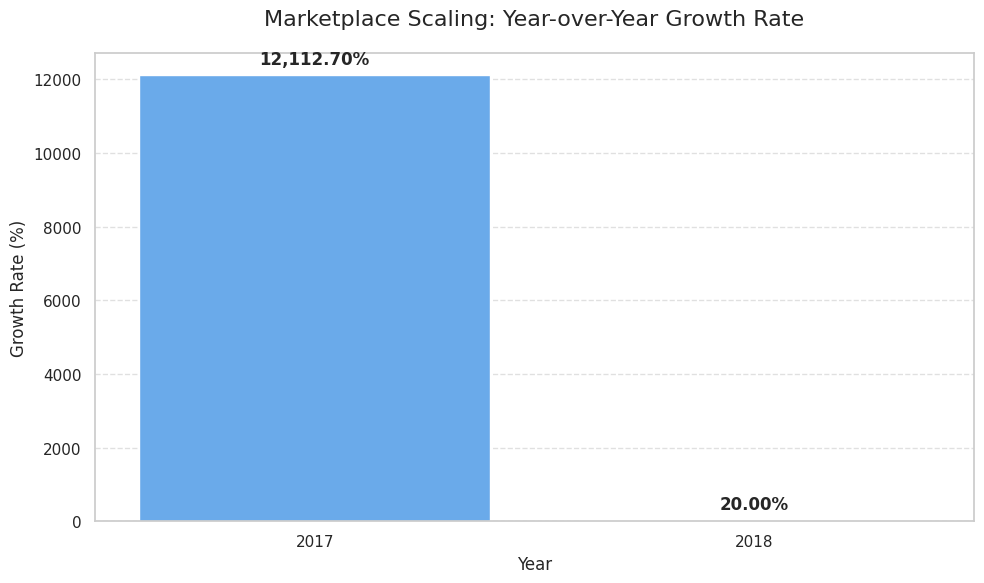

In [35]:
# Link orders to their total payment values
order_pay_totals = payments.groupby('order_id')['payment_value'].sum().reset_index()
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['year'] = orders['order_purchase_timestamp'].dt.year

annual_df = pd.merge(orders[['order_id', 'year']], order_pay_totals, on='order_id')

# Sum sales per year
annual_sales = annual_df.groupby('year')['payment_value'].sum().reset_index()
annual_sales.columns = ['Year', 'Total Sales']

# Percentage change from previous year
annual_sales['YoY Growth Rate (%)'] = annual_sales['Total Sales'].pct_change() * 100

# Table
print("Table: Year-over-Year (YoY) Sales Growth")
display(annual_sales)

# Visual
plt.figure(figsize=(10, 6))
# We filter for years that actually have a growth calculation (2017 and 2018)
growth_only = annual_sales.dropna(subset=['YoY Growth Rate (%)'])

sns.barplot(data=growth_only, x='Year', y='YoY Growth Rate (%)', palette='cool')

plt.title('Marketplace Scaling: Year-over-Year Growth Rate', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Growth Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adding value labels for clarity
for i, val in enumerate(growth_only['YoY Growth Rate (%)']):
    plt.text(i, val + 200, f'{val:,.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

4. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

Table: 6-Month Customer Retention Analysis


,Metric,Count,Percentage
0,Total Unique Customers,96096,100%
1,Retained (Repeat within 6mo),1608,1.67%
2,One-time Buyers,94488,98.33%


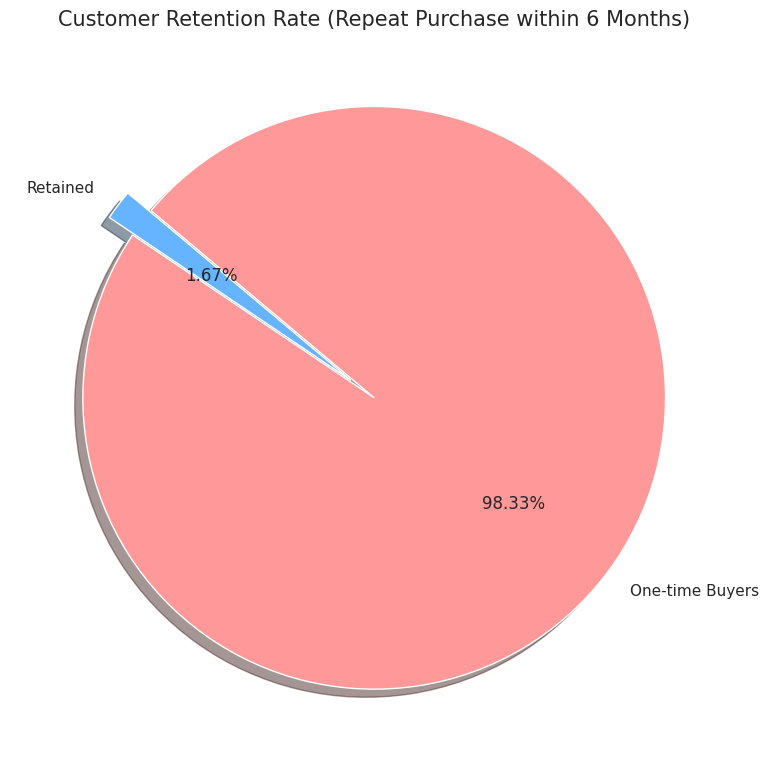

In [36]:
# Link Orders to Unique Customer IDs
# We must use customer_unique_id to track the same person over time
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
user_orders = pd.merge(orders[['customer_id', 'order_purchase_timestamp']],
                       customers[['customer_id', 'customer_unique_id']],
                       on='customer_id')

# Identify the First Purchase for every user
first_purchase_map = user_orders.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_purchase_map.columns = ['customer_unique_id', 'first_purchase_date']

# Check for subsequent purchases within 6 months (180 days)
# Join the first purchase date back to all orders
retention_df = pd.merge(user_orders, first_purchase_map, on='customer_unique_id')

# Calculate the gap in days
retention_df['days_since_first'] = (retention_df['order_purchase_timestamp'] - retention_df['first_purchase_date']).dt.days

# A customer is "Retained" if they have a purchase where: 0 < days <= 180
retained_users = retention_df[(retention_df['days_since_first'] > 0) &
                              (retention_df['days_since_first'] <= 180)]['customer_unique_id'].unique()

# Aggregation
total_users = user_orders['customer_unique_id'].nunique()
retained_count = len(retained_users)
retention_rate = (retained_count / total_users) * 100

# Table
retention_table = pd.DataFrame({
    'Metric': ['Total Unique Customers', 'Retained (Repeat within 6mo)', 'One-time Buyers'],
    'Count': [total_users, retained_count, total_users - retained_count],
    'Percentage': ['100%', f'{retention_rate:.2f}%', f'{100 - retention_rate:.2f}%']
})

print("Table: 6-Month Customer Retention Analysis")
display(retention_table)

# Visual
plt.figure(figsize=(8, 8))
plt.pie([retained_count, total_users - retained_count],
        labels=['Retained', 'One-time Buyers'],
        autopct='%1.2f%%',
        startangle=140,
        colors=['#66b3ff', '#ff9999'],
        explode=(0.1, 0),
        shadow=True)

plt.title('Customer Retention Rate (Repeat Purchase within 6 Months)', fontsize=15)
plt.tight_layout()
plt.show()

5. Identify the top 3 customers who spent the most money in each year.

Table: Top 3 Highest Spending Customers per Year


,year,customer_unique_id,payment_value
319,2016,fdaa290acb9eeacb66fa7f979baa6803,1423.55
145,2016,753bc5d6efa9e49a03e34cf521a9e124,1400.74
234,2016,b92a2e5e8a6eabcc80882c7d68b2c70b,1227.78
2075,2017,0a0a92112bd4c708ca5fde585afaa872,13664.08
37662,2017,da122df9eeddfedc1dc1f5349a1a690c,7571.63
38033,2017,dc4802a71eae9be1dd28f5d788ceb526,6929.31
58553,2018,46450c74a0d8c5ca9395da1daac6c120,9553.02
68456,2018,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
58410,2018,459bef486812aa25204be022145caa62,6922.21


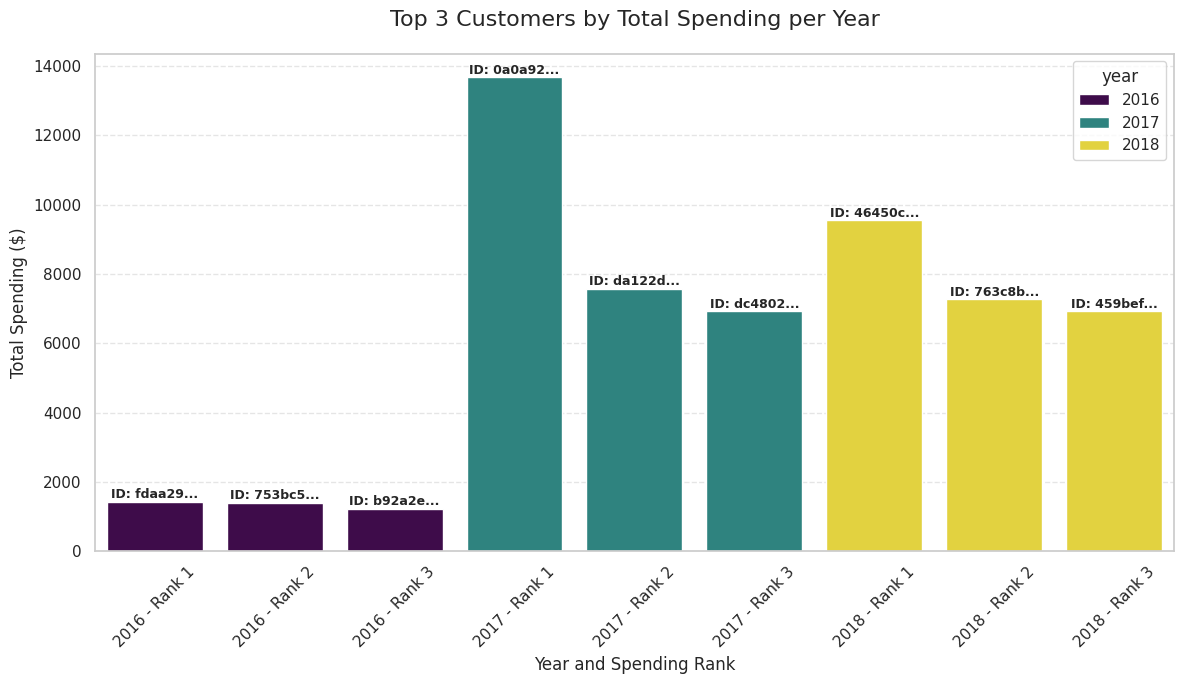

In [37]:
# Sum payments per order
order_pay_totals = payments.groupby('order_id')['payment_value'].sum().reset_index()

# Link orders to years and unique customer IDs
orders['year'] = orders['order_purchase_timestamp'].dt.year

df = pd.merge(orders[['order_id', 'year', 'customer_id']], order_pay_totals, on='order_id')
df = pd.merge(df, customers[['customer_id', 'customer_unique_id']], on='customer_id')

# Group by Year and Unique Customer
customer_yearly_spending = df.groupby(['year', 'customer_unique_id'])['payment_value'].sum().reset_index()

# Get Top 3 per Year
top_3_per_year = customer_yearly_spending.sort_values(['year', 'payment_value'], ascending=[True, False]).groupby('year').head(3)

# Table
print("Table: Top 3 Highest Spending Customers per Year")
display(top_3_per_year)

# Visual
plt.figure(figsize=(12, 7))
# Create labels for bars (Year + Rank)
top_3_per_year['Rank'] = top_3_per_year.groupby('year')['payment_value'].rank(ascending=False, method='first').astype(int)
top_3_per_year['Plot_Label'] = top_3_per_year['year'].astype(str) + " - Rank " + top_3_per_year['Rank'].astype(str)

sns.barplot(data=top_3_per_year, x='Plot_Label', y='payment_value', hue='year', dodge=False, palette='viridis')

plt.title('Top 3 Customers by Total Spending per Year', fontsize=16, pad=20)
plt.xlabel('Year and Spending Rank', fontsize=12)
plt.ylabel('Total Spending ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adding partial customer IDs as labels on top of the bars
for i, row in enumerate(top_3_per_year.itertuples()):
    plt.text(i, row.payment_value + 100, f"ID: {row.customer_unique_id[:6]}...", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary & Insights

1.   Market Concentration & Logistics
Insight: The business is heavily concentrated in the Southeast, with São Paulo (SP) and Rio de Janeiro (RJ) accounting for over 50% of the customer base. Interestingly, customers in smaller cities have a significantly higher average item count per order (e.g., Padre Carvalho at 7.0 items).

**Recommendation:** Optimize logistics for "bulk" deliveries to smaller/remote cities. For high-density hubs like SP, focus on "Same-Day" or "Next-Day" delivery to maintain a competitive edge.

2.   The Power of "Buy Now, Pay Later"
Insight: More than 51.4% of orders are paid via installments. This flexibility is a core pillar of the marketplace's sales strategy.

**Recommendation:** Continue to partner with financial providers to offer low-interest or interest-free installments, as this directly enables the purchase of high-ticket items in the "Watches" and "Health/Beauty" categories.

3.   The Retention Gap
Insight: Our advanced analysis revealed a retention rate of only 1.67% within a 6-month window. The marketplace is excellent at acquiring new users but struggles to keep them.

**Recommendation:** Implement a Loyalty/Rewards Program. Since the "Health & Beauty" category is a top performer and usually involves recurring needs, targeted subscription models or "buy-it-again" discounts could significantly boost the repeat purchase rate.

4.   Scaling and Seasonality
Insight: The business experienced explosive growth, with 2018 sales already surpassing 2017 by August. November is the critical "make-or-break" month due to the Black Friday spike seen in 2017.

**Recommendation:** Prepare seller inventory and server capacity specifically for the Q4 surge. Marketing spend should be maximized in October to "warm up" the customer base for November.

/tmp/ipython-input-164/3494108673.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], data=state_counts.head(5), x='State', y='Customer Count', palette='Blues_r')
/tmp/ipython-input-164/3494108673.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], data=top_10_contribution.head(5), x='Percentage (%)', y='Product Category', palette='viridis')


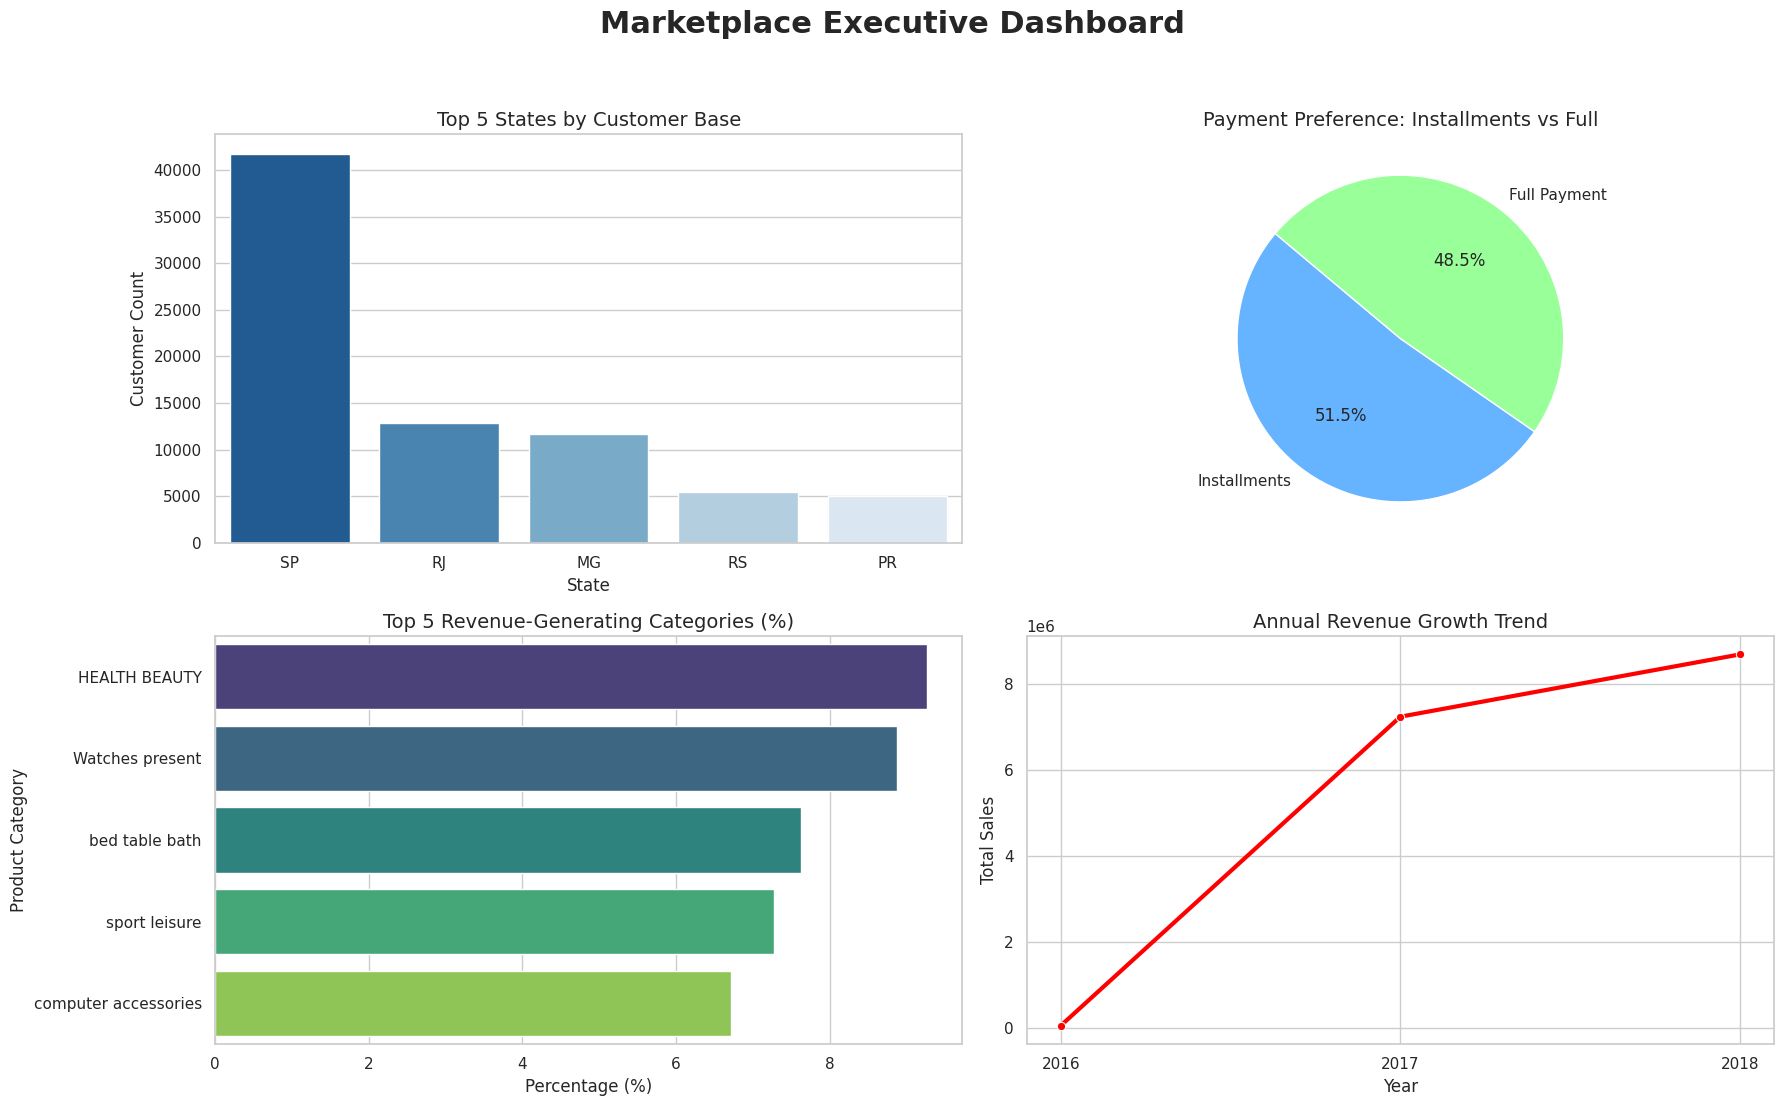

In [38]:
# Create a 2x2 Summary Dashboard
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Marketplace Executive Dashboard', fontsize=22, fontweight='bold', y=0.95)

# 1. Top States (Bar)
sns.barplot(ax=axes[0, 0], data=state_counts.head(5), x='State', y='Customer Count', palette='Blues_r')
axes[0, 0].set_title('Top 5 States by Customer Base', fontsize=14)

# 2. Payment Methods (Pie)
axes[0, 1].pie(installment_stats['Total Orders'], labels=installment_stats['Payment Method'],
               autopct='%1.1f%%', colors=['#66b3ff','#99ff99'], startangle=140)
axes[0, 1].set_title('Payment Preference: Installments vs Full', fontsize=14)

# 3. Revenue by Category (Horizontal Bar)
sns.barplot(ax=axes[1, 0], data=top_10_contribution.head(5), x='Percentage (%)', y='Product Category', palette='viridis')
axes[1, 0].set_title('Top 5 Revenue-Generating Categories (%)', fontsize=14)

# 4. Yearly Growth (Line)
sns.lineplot(ax=axes[1, 1], data=annual_sales, x='Year', y='Total Sales', marker='o', color='red', linewidth=3)
axes[1, 1].set_title('Annual Revenue Growth Trend', fontsize=14)
axes[1, 1].set_xticks([2016, 2017, 2018])

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()